In [903]:
import math

import numpy as np
import cupy as cp
import numba as nb
import numba.cuda
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.ndimage
import scipy.sparse.csgraph
import rasterio

In [2]:
def point_in_disk(radius=50, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = x**2 + y**2 <= linewidth**2
    small_disk = np.sum(np.sum(disk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small_minidisk = np.sum(np.sum(minidisk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small_disk[small_minidisk > 0] = 0
    small_disk = -small_disk / np.sum(small_disk)
    small_disk[small_minidisk > 0] = 1 / np.sum(small_minidisk > 0)
    return small_disk

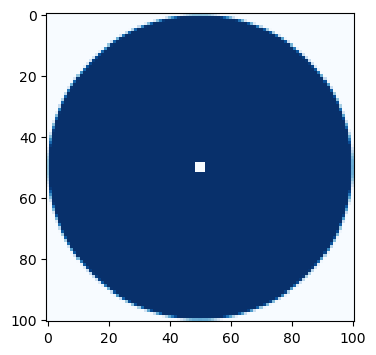

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))

tmp = point_in_disk()
ax.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")

None

In [4]:
def line_in_disk(angle, radius=50, linelength=15, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = np.exp(-(x**2 + y**2) / 2 / linelength**2) / np.sqrt(2 * np.pi * linelength**2)
    line = np.abs(x * np.sin(-angle * np.pi/180) - y * np.cos(angle * np.pi/180)) < linewidth
    centerline = minidisk * (disk & line)
    big = -(disk / np.sum(disk)) + (centerline / np.sum(centerline))
    small = np.sum(np.sum(big.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    return small

3.608224830031759e-16


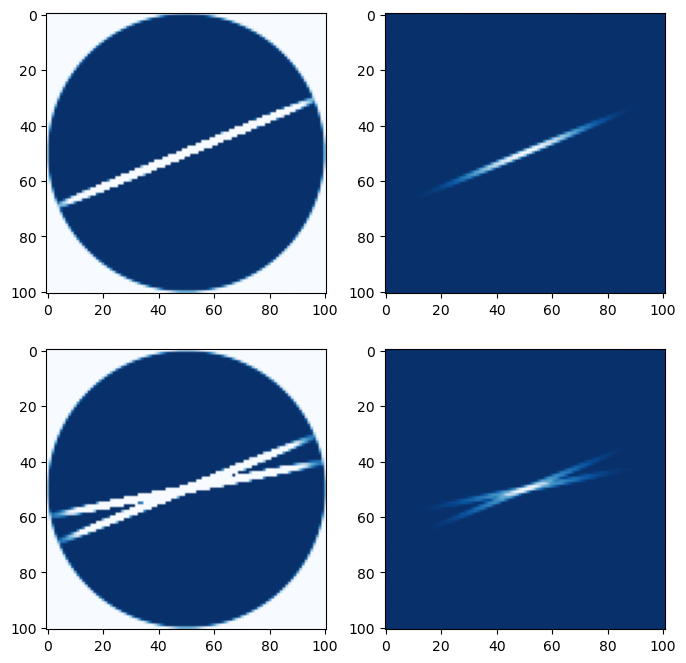

In [5]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))

tmp = line_in_disk(22.5)
tmp2 = line_in_disk(11.25)
print(np.sum(tmp))

ax1.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")
ax2.imshow(tmp, vmin=0, vmax=np.nanmax(tmp), cmap="Blues_r")
ax3.imshow(tmp + tmp2, vmin=np.nanmin(tmp + tmp2), vmax=0, cmap="Blues_r")
ax4.imshow(tmp + tmp2, vmin=0, vmax=np.nanmax(tmp + tmp2), cmap="Blues_r")

None

In [6]:
with rasterio.open("../data/Sonoma_DTM_2022-OAEC-0.01-degree.tif") as file:
    elevation = file.read(1)
    transform = file.transform
    crs = file.crs

In [7]:
small_image = elevation[1800:2900, 600:1500]

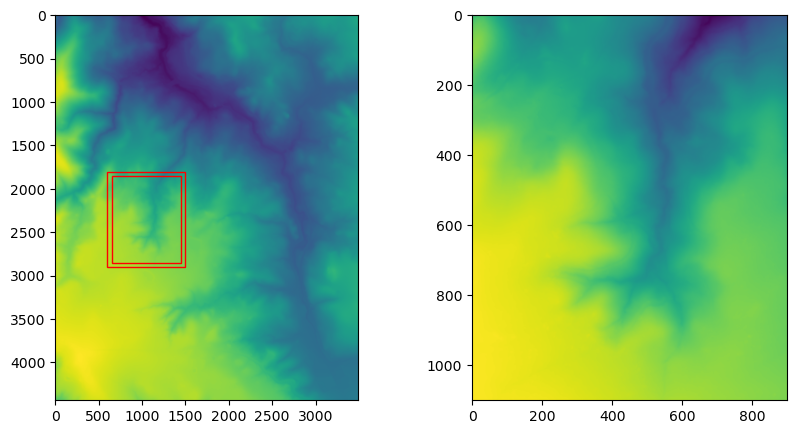

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(elevation)
ax1.add_patch(mpl.patches.Rectangle((600, 1800), 1500 - 600, 2900 - 1800, edgecolor="red", facecolor="none"))
ax1.add_patch(mpl.patches.Rectangle((600 + 50, 1800 + 50), 1500 - 600 - 100, 2900 - 1800 - 100, edgecolor="red", facecolor="none"))

ax2.imshow(small_image)

None

In [9]:
_convolve2dkernel = {}

def convolve2d(image, multikernel):
    image = cp.asarray(image, dtype=np.float32)
    multikernel = cp.asarray(multikernel, dtype=np.float32)
    output = cp.zeros(multikernel.shape[:1] + image.shape, image.dtype)

    key = (image.shape, multikernel.shape)
    if key not in _convolve2dkernel:
        imageI, imageJ = image.shape
        kernelI, kernelJ = multikernel.shape[1:]
        num_angles = multikernel.shape[0]

        @nb.cuda.jit
        def fcn(image, multikernel, output):
            ang, imi, imj = nb.cuda.grid(3)
            if imi >= imageI or imj >= imageJ:
                return

            halfi = kernelI // 2
            halfj = kernelJ // 2

            accumulate = 0
            for ki in range(kernelI):
                for kj in range(kernelJ):
                    # boundary conditions that reflect
                    i = abs(imi + ki - halfi)
                    j = abs(imj + kj - halfj)
                    i = i if i < imageI else 2*imageI - i - 1
                    j = j if j < imageJ else 2*imageJ - j - 1
                    accumulate += image[i, j] * multikernel[ang, ki, kj]

            output[ang, imi, imj] = accumulate

        _convolve2dkernel[key] = fcn

    threadsperblock = (16, 8, 8)
    blockspergrid_i = int(np.ceil(image.shape[0] / threadsperblock[1]))
    blockspergrid_j = int(np.ceil(image.shape[1] / threadsperblock[2]))
    blockspergrid = (1, blockspergrid_i, blockspergrid_j)

    _convolve2dkernel[key][blockspergrid, threadsperblock](image, multikernel, output)
    return output.get()

In [40]:
convolution_point = convolve2d(small_image, np.stack([point_in_disk() for angle in np.arange(0, 180, 11.25)]))[:, 50:-50, 50:-50]

In [41]:
convolution_angle = convolve2d(small_image, np.stack([line_in_disk(angle) for angle in np.arange(0, 180, 11.25)]))[:, 50:-50, 50:-50]

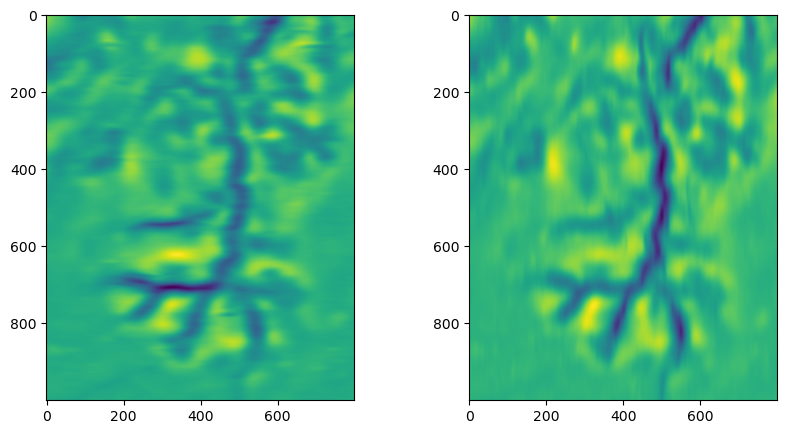

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(convolution_angle[0, :, :])
ax2.imshow(convolution_angle[8, :, :])

None

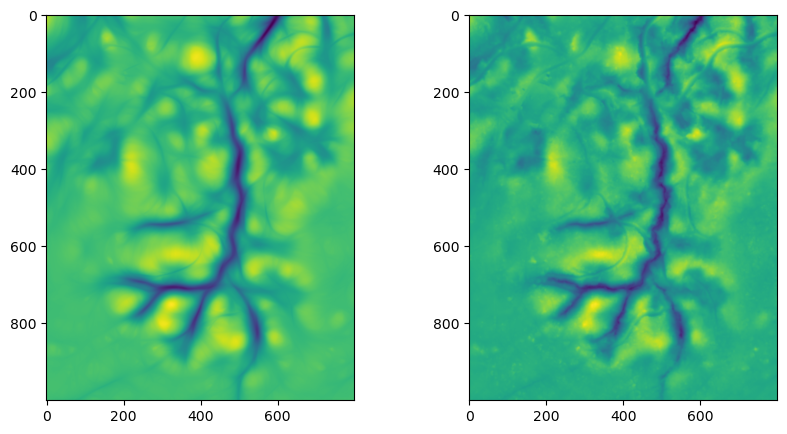

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(np.min(convolution_angle, axis=0))
ax2.imshow(np.min(convolution_point, axis=0))

None

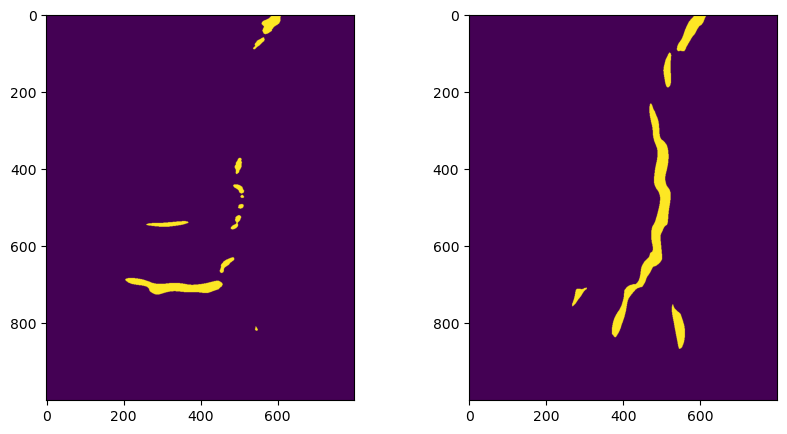

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(convolution_angle[0, :, :] < -3)
ax2.imshow(convolution_angle[8, :, :] < -3)

None

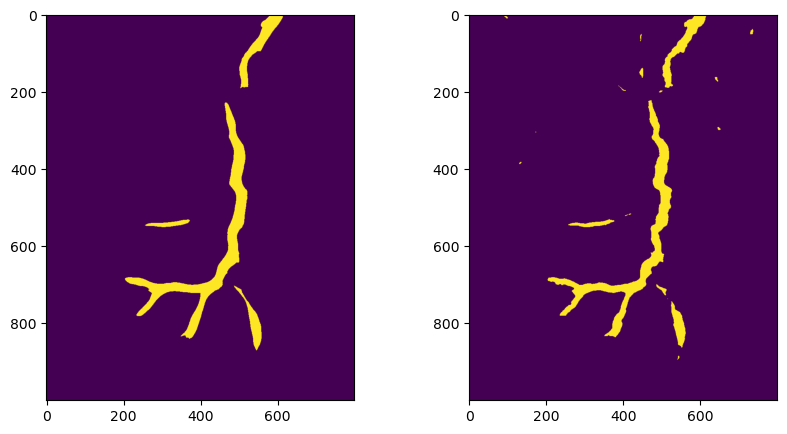

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(np.min(convolution_angle, axis=0) < -3)
ax2.imshow(np.min(convolution_point, axis=0) < -3)

None

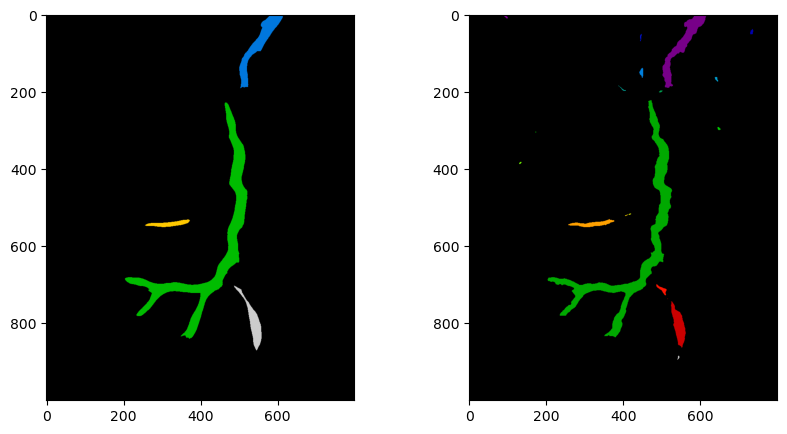

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

all8corners = scipy.ndimage.generate_binary_structure(2, 2)

ax1.imshow(scipy.ndimage.label(np.min(convolution_angle, axis=0) < -3, all8corners)[0], vmin=0, cmap="nipy_spectral")
ax2.imshow(scipy.ndimage.label(np.min(convolution_point, axis=0) < -3, all8corners)[0], vmin=0, cmap="nipy_spectral")

None

In [392]:
def amplitude_angle_offset(theta1, y1, theta2, y2, theta3, y3, theta4, y4):
    # Basis at 2*theta
    s1, c1 = np.sin(2.0*theta1), np.cos(2.0*theta1)
    s2, c2 = np.sin(2.0*theta2), np.cos(2.0*theta2)
    s3, c3 = np.sin(2.0*theta3), np.cos(2.0*theta3)
    s4, c4 = np.sin(2.0*theta4), np.cos(2.0*theta4)

    # Sums
    sum_s = s1 + s2 + s3 + s4
    sum_c = c1 + c2 + c3 + c4
    sum_y = y1 + y2 + y3 + y4

    sum_ss = s1*s1 + s2*s2 + s3*s3 + s4*s4
    sum_cc = c1*c1 + c2*c2 + c3*c3 + c4*c4
    sum_sc = s1*c1 + s2*c2 + s3*c3 + s4*c4

    sum_ys = y1*s1 + y2*s2 + y3*s3 + y4*s4
    sum_yc = y1*c1 + y2*c2 + y3*c3 + y4*c4

    # Means
    inv_n = 0.25  # 1/4
    s_bar = sum_s * inv_n
    c_bar = sum_c * inv_n
    y_bar = sum_y * inv_n

    # Centered normal-equation pieces for [B D]^T
    Sss = sum_ss - 4.0 * s_bar * s_bar
    Scc = sum_cc - 4.0 * c_bar * c_bar
    Scs = sum_sc - 4.0 * s_bar * c_bar
    Sys = sum_ys - 4.0 * y_bar * s_bar
    Syc = sum_yc - 4.0 * y_bar * c_bar

    det = Sss * Scc - Scs * Scs

    eps = 1e-12
    inv_det = 1.0 / (det + np.copysign(eps, det))
    B = (Sys * Scc - Syc * Scs) * inv_det
    D = (Syc * Sss - Sys * Scs) * inv_det

    # Offset once B, D are known
    C = y_bar - B * s_bar - D * c_bar

    # Convert back to amplitude & phase
    A = np.hypot(B, D)        # sqrt(B^2 + D^2), guaranteed >= 0
    phi = np.atan2(D, B)      # (-pi, pi]

    return A, phi, C

In [494]:
def amplitude_angle_offset(samples):
    # Accumulate sums for normal equations
    S_ss = S_cc = S_sc = S_s = S_c = S_y = S_ys = S_yc = 0.0
    n = 0
    for theta, y in samples:
        s = np.sin(2.0 * theta)
        c = np.cos(2.0 * theta)
        S_ss += s * s
        S_cc += c * c
        S_sc += s * c
        S_s  += s
        S_c  += c
        S_y  += y
        S_ys += y * s
        S_yc += y * c
        n += 1

    # Solve the 3x3 system:
    # [ S_ss  S_sc  S_s ] [alpha] = [ S_ys ]
    # [ S_sc  S_cc  S_c ] [beta ]   [ S_yc ]
    # [ S_s   S_c    n  ] [c    ]   [ S_y  ]

    def det3(a11,a12,a13, a21,a22,a23, a31,a32,a33):
        return (a11*(a22*a33 - a23*a32)
              - a12*(a21*a33 - a23*a31)
              + a13*(a21*a32 - a22*a31))

    # Main determinant
    D = det3(S_ss, S_sc, S_s,
             S_sc, S_cc, S_c,
             S_s,  S_c,  n)

    eps = 1e-14

    # Cramer's rule
    D_alpha = det3(S_ys, S_sc, S_s,
                   S_yc, S_cc, S_c,
                   S_y,  S_c,  n)

    D_beta  = det3(S_ss, S_ys, S_s,
                   S_sc, S_yc, S_c,
                   S_s,  S_y,  n)

    D_c     = det3(S_ss, S_sc, S_ys,
                   S_sc, S_cc, S_yc,
                   S_s,  S_c,  S_y)

    alpha = D_alpha / D
    beta  = D_beta  / D
    c     = D_c     / D

    amplitude = np.hypot(alpha, beta)        # sqrt(alpha^2 + beta^2)
    angle     = np.atan2(beta, alpha)        # in radians
    offset    = c

    return amplitude, angle, offset

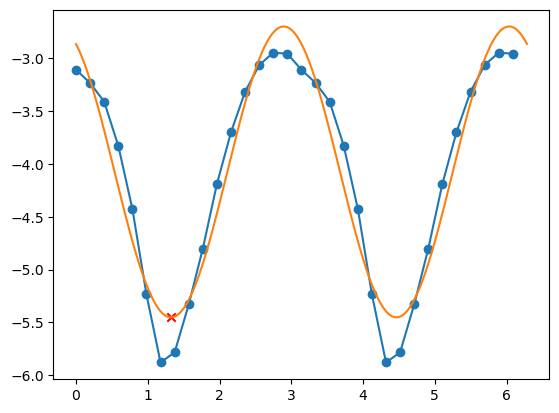

In [768]:
fig, ax = plt.subplots()

_, i, j = sorted([
    (convolution_angle[:, i, j].min(), i, j)
     for i, j in zip(np.random.randint(0, convolution_angle.shape[1], 100), np.random.randint(0, convolution_angle.shape[2], 100))
])[0]

pixel = convolution_angle[:, i, j]

x = np.arange(0, 180, 11.25) * np.pi/180
ax.plot(x.tolist() + (x + np.pi).tolist(), pixel.tolist() * 2, marker="o")

amplitude, angle, offset = amplitude_angle_offset(zip(x, pixel))
x = np.linspace(0, 2*np.pi, 320)
y = amplitude * np.sin(2*x + angle) + offset
ax.plot(x, y)

bestx = ((-np.pi/2 - angle) / 2) % np.pi
besty = amplitude * np.sin(2*bestx + angle) + offset
ax.scatter([bestx], [besty], color="red", marker="x")

# [
#     (theta1, sample1),
#     (theta2, sample2),
#     (theta3, sample3),
#     (theta4, sample4),
# ] = sorted(zip(np.linspace(0, np.pi, 16), pixel), key=lambda pair: abs(pair[0] - bestx))[:4]

# amplitude, angle, offset = amplitude_angle_offset(theta1, sample1, theta2, sample2, theta3, sample3, theta4, sample4)
# x = np.linspace(0, 2*np.pi, 320)
# y = amplitude * np.sin(2*x + angle) + offset
# ax.plot(x, y)

None

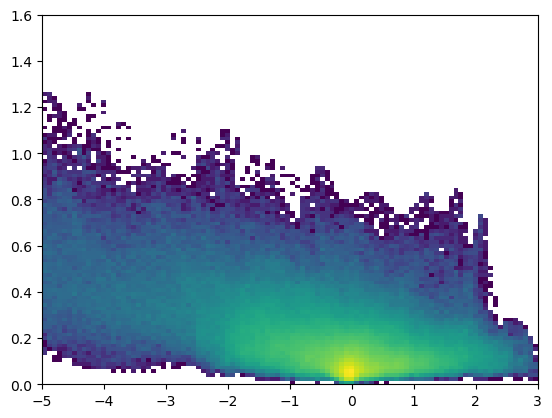

In [782]:
fig, ax = plt.subplots()

x = (np.arange(0, 180, 11.25) * np.pi/180)[:, np.newaxis, np.newaxis]

amplitudes, angles, offsets = amplitude_angle_offset(zip(x, convolution_angle))

y = amplitudes * np.sin(2*x + angles) + offsets

chi2 = np.sqrt(np.sum(((convolution_angle - y)**2), axis=0))

i, j = np.meshgrid(np.arange(y.shape[2]), np.arange(y.shape[1]))
fit_minimum = y[np.argmin(convolution_angle, axis=0), j, i]
data_minimum = np.min(convolution_angle, axis=0)

# ax.hist2d(data_minimum.flatten(), (fit_minimum - data_minimum).flatten(), bins=(100, 100), range=((-5, 3), (-1, 1)), norm=mpl.colors.LogNorm())

ax.hist2d(data_minimum.flatten(), chi2.flatten(), bins=(100, 100), range=((-5, 3), (0, 1.6)), norm=mpl.colors.LogNorm())

None

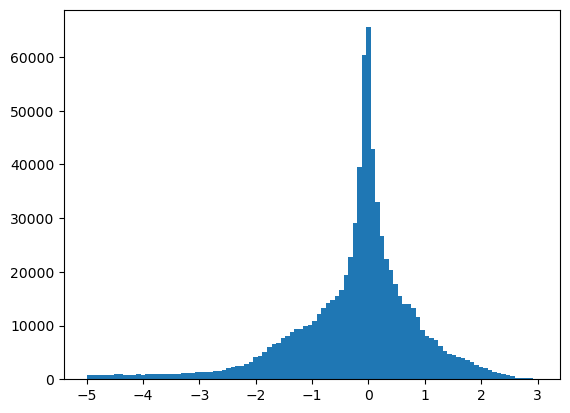

In [781]:
fig, ax = plt.subplots()

ax.hist(data_minimum.flatten(), bins=100, range=(-5, 3))

None

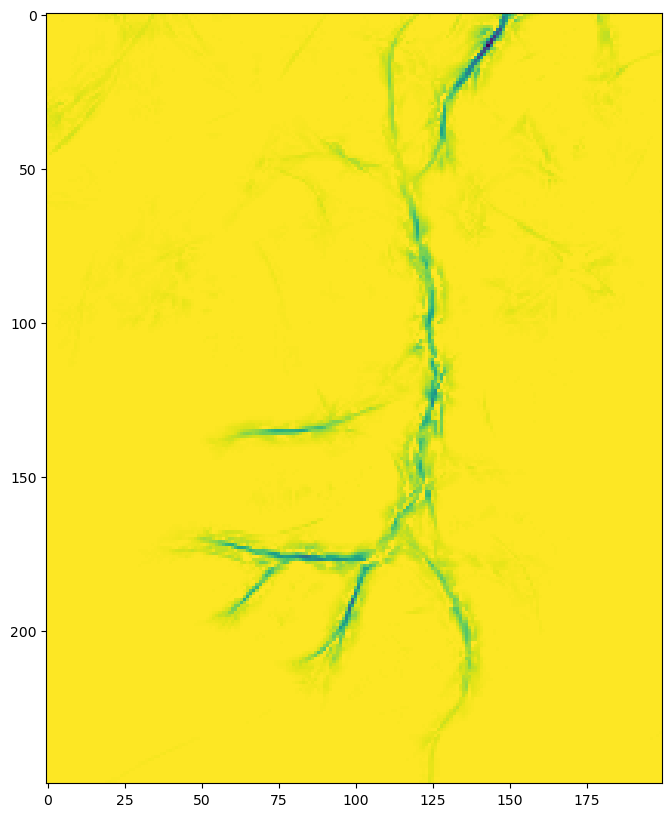

In [801]:
fig, ax = plt.subplots(figsize=(10, 10))

x = (np.arange(0, 180, 11.25) * np.pi/180)[:, np.newaxis, np.newaxis]

amplitudes, angles, offsets = amplitude_angle_offset(zip(x, convolution_angle))

y = amplitudes * np.sin(2*x + angles) + offsets

chi2 = np.sqrt(np.sum(((convolution_angle - y)**2), axis=0))

i, j = np.meshgrid(np.arange(y.shape[2]), np.arange(y.shape[1]))
fit_minimum = y[np.argmin(convolution_angle, axis=0), j, i]
data_minimum = np.min(convolution_angle, axis=0)

ax.imshow(scipy.ndimage.zoom(data_minimum * (fit_minimum - data_minimum), 1/4, order=2), vmax=0)

None

In [802]:
def best_fit(theta1, y1, theta2, y2, theta3, y3, theta4, y4):
    # Basis at 2*theta (unrolled for 4 points)
    s1, c1 = np.sin(2.0*theta1), np.cos(2.0*theta1)
    s2, c2 = np.sin(2.0*theta2), np.cos(2.0*theta2)
    s3, c3 = np.sin(2.0*theta3), np.cos(2.0*theta3)
    s4, c4 = np.sin(2.0*theta4), np.cos(2.0*theta4)

    # Sums
    sum_s = s1 + s2 + s3 + s4
    sum_c = c1 + c2 + c3 + c4
    sum_y = y1 + y2 + y3 + y4

    sum_ss = s1*s1 + s2*s2 + s3*s3 + s4*s4
    sum_cc = c1*c1 + c2*c2 + c3*c3 + c4*c4
    sum_sc = s1*c1 + s2*c2 + s3*c3 + s4*c4

    sum_ys = y1*s1 + y2*s2 + y3*s3 + y4*s4
    sum_yc = y1*c1 + y2*c2 + y3*c3 + y4*c4

    # Means
    inv_n = 0.25  # 1/4
    s_bar = sum_s * inv_n
    c_bar = sum_c * inv_n
    y_bar = sum_y * inv_n

    # Centered normal-equation pieces for [B, C]^T
    # (centering eliminates A from the 2x2)
    Sss = sum_ss - 4.0 * s_bar * s_bar
    Scc = sum_cc - 4.0 * c_bar * c_bar
    Scs = sum_sc - 4.0 * s_bar * c_bar
    Sys = sum_ys - 4.0 * y_bar * s_bar
    Syc = sum_yc - 4.0 * y_bar * c_bar

    det = Sss * Scc - Scs * Scs

    # Branchless inverse determinant with tiny signed bias.
    # Scale eps to data magnitude for robustness.
    scale = abs(Sss) + abs(Scc) + abs(Scs) + 1.0
    eps = 1e-12 * scale
    inv_det = 1.0 / (det + np.copysign(eps, det))

    # Solve the 2x2 for (B, C)
    B = (Sys * Scc - Syc * Scs) * inv_det
    C = (Syc * Sss - Sys * Scs) * inv_det

    # Recover A from the mean constraint
    A = y_bar - B * s_bar - C * c_bar

    return A, B, C

In [817]:
def best_fit(y0, y45, y90, y135):
    A = 0.25 * (y0 + y45 + y90 + y135)
    B = 0.5  * (y45 - y135)
    C = 0.5  * (y0 - y90)
    return A, B, C

In [914]:
def best_fit(y0, y1, y2, y3, y4, y5, y6, y7):
    # 1/sqrt(2) for sin/cos(π/4)
    SQRT1_2 = 0.7071067811865475244

    inv8 = 0.125   # 1/8
    inv4 = 0.25    # 1/4

    # Mean (orthogonality ⇒ A is just the average)
    A = inv8 * (y0 + y1 + y2 + y3 + y4 + y5 + y6 + y7)

    # Helper combos for the π/4-valued sines/cosines
    t1 = (y1 + y3) - (y5 + y7)      # weights for sin terms at ±π/4
    t2 = (y1 - y3) - (y5 - y7)      # weights for cos terms at ±π/4

    # Using: sum_k sin^2(2θk) = sum_k cos^2(2θk) = 4, cross-terms vanish
    B = inv4 * ((y2 - y6) + SQRT1_2 * t1)
    C = inv4 * ((y0 - y4) + SQRT1_2 * t2)

    return A, B, C

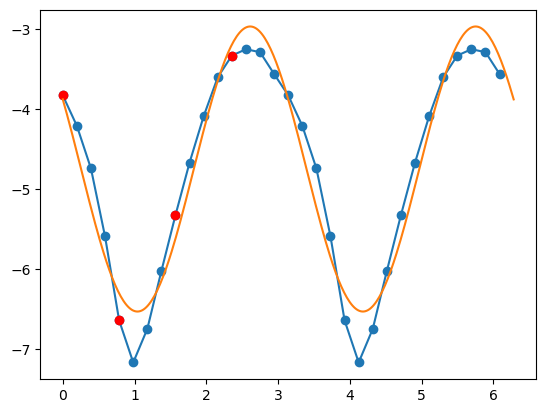

In [937]:
fig, ax = plt.subplots()

_, i, j = sorted([
    (convolution_angle[:, i, j].min(), i, j)
     for i, j in zip(np.random.randint(0, convolution_angle.shape[1], 10000), np.random.randint(0, convolution_angle.shape[2], 10000))
])[0]

pixel = convolution_angle[:, i, j]

x = np.arange(0, 180, 11.25) * np.pi/180
ax.plot(x.tolist() + (x + np.pi).tolist(), pixel.tolist() * 2, marker="o")
ax.plot(x[[0, 4, 8, 12]], pixel[[0, 4, 8, 12]], color="red", marker="o", lw=0)

A, B, C = best_fit(pixel[0], pixel[2], pixel[4], pixel[6], pixel[8], pixel[10], pixel[12], pixel[14])
x = np.linspace(0, 2*np.pi, 320)
y = A + B*np.sin(2*x) + C*np.cos(2*x)
ax.plot(x, y)

None

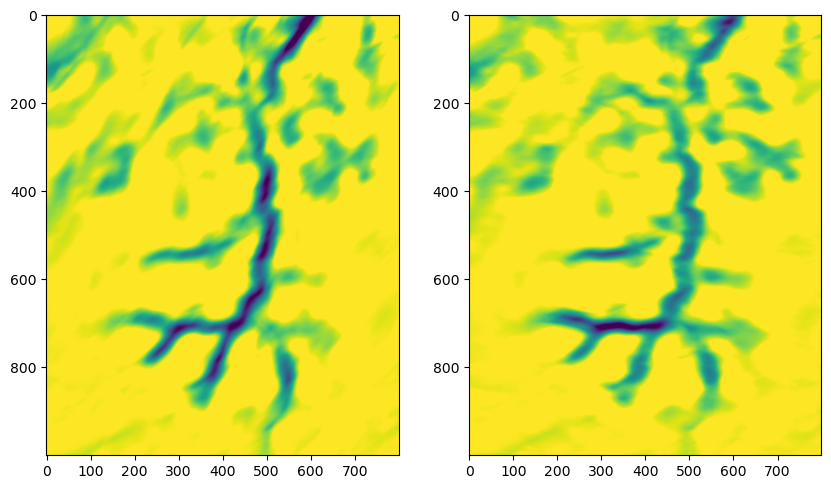

In [970]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7))

A, B, C = best_fit(*convolution_angle[::2])

vpooling = A + B
vpooling[1:, :] = vpooling[1:, :] + vpooling[:-1, :]
ax1.imshow(vpooling, vmin=-10, vmax=0)

hpooling = A + C
hpooling[:, 1:] = hpooling[:, 1:] + hpooling[:, :-1]
ax2.imshow(hpooling, vmin=-10, vmax=0)

None

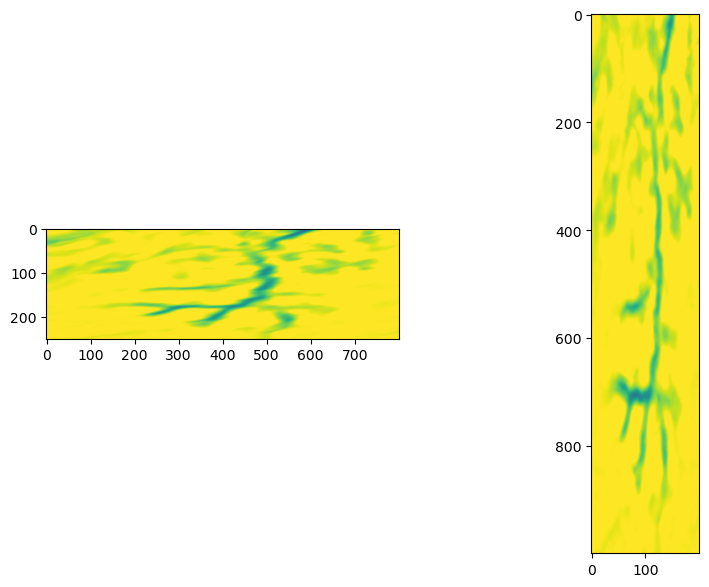

In [972]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7))

A, B, C = best_fit(*convolution_angle[::2])

vpooling = A + B
vpooling = vpooling[:vpooling.shape[0] // 4 * 4, :].reshape(-1, 4, vpooling.shape[1]).mean(axis=1)
ax1.imshow(vpooling, vmin=-10, vmax=0)

hpooling = A + C
hpooling = hpooling[:, :hpooling.shape[1] // 4 * 4].reshape(hpooling.shape[0], -1, 4).mean(axis=2)
ax2.imshow(hpooling, vmin=-10, vmax=0)

None

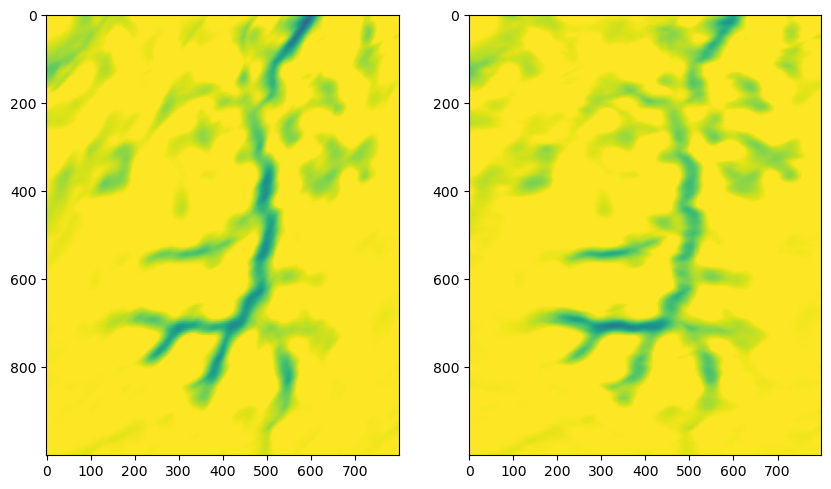

In [973]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7))

A, B, C = best_fit(*convolution_angle[::2])

vpooling = A + B
vpooling = np.repeat(vpooling[:vpooling.shape[0] // 4 * 4, :].reshape(-1, 4, vpooling.shape[1]).mean(axis=1), 4, axis=0)
ax1.imshow(vpooling, vmin=-10, vmax=0)

hpooling = A + C
hpooling = np.repeat(hpooling[:, :hpooling.shape[1] // 4 * 4].reshape(hpooling.shape[0], -1, 4).mean(axis=2), 4, axis=1)
ax2.imshow(hpooling, vmin=-10, vmax=0)

None

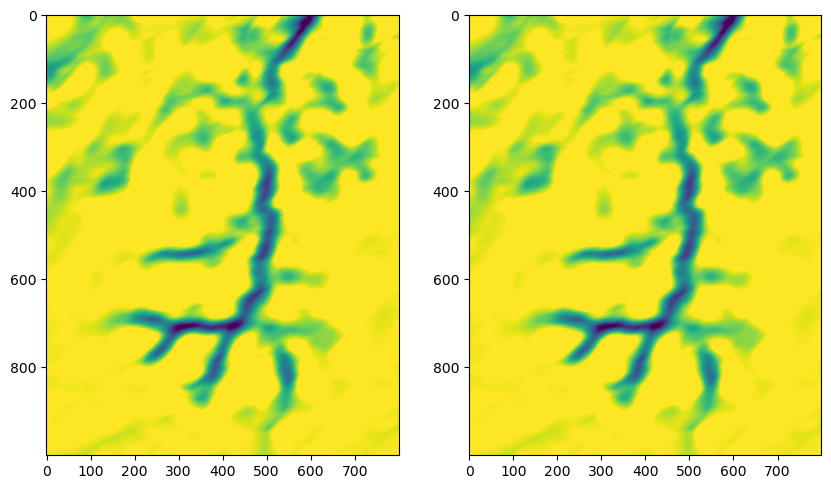

In [974]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7))

A, B, C = best_fit(*convolution_angle[::2])

vpooling = A + B
hpooling = A + C

ax1.imshow(vpooling + hpooling, vmin=-10, vmax=0)

vpooling = np.repeat(vpooling[:vpooling.shape[0] // 4 * 4, :].reshape(-1, 4, vpooling.shape[1]).mean(axis=1), 4, axis=0)
hpooling = np.repeat(hpooling[:, :hpooling.shape[1] // 4 * 4].reshape(hpooling.shape[0], -1, 4).mean(axis=2), 4, axis=1)

ax2.imshow(vpooling + hpooling, vmin=-10, vmax=0)

None